# Systems Conference Topic Explorer

Five interactive visualisations of how systems research topics evolved from 2006 to 2025,
based on the DBLP bibliography dump (4,654 papers across 84 conference editions).

**Cell 3** calls the Anthropic API to name clusters — results cached in `data/cluster_labels.json`.

In [1]:
import sys
from pathlib import Path

repo = Path.cwd().parent
if str(repo / "src") not in sys.path:
    sys.path.insert(0, str(repo / "src"))

import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

from viz_sys_conferences.viz_data import load_editions
from viz_sys_conferences.viz_plots import (
    papers_over_time,
    keyword_heatmap_matrix,
    topic_trends_from_embeddings,
    conference_similarity,
)

DATA_DIR = repo / "data"
editions = load_editions(DATA_DIR)
print(f"Loaded {len(editions)} editions, {sum(len(e['papers']) for e in editions)} papers")

Loaded 84 editions, 4654 papers


## 1 · Papers over time

A stacked bar chart showing the total number of accepted papers per year for each
of the five conferences (OSDI, NSDI, ATC, SOSP, EuroSys).

**Data source:** DBLP XML dump (`dblp.xml.gz`), filtered to `<inproceedings>` entries
whose key matches the venue prefixes `conf/osdi/`, `conf/nsdi/`, `conf/usenix/`,
`conf/sosp/`, `conf/eurosys/`. Paper counts per year are taken directly from the
dump — no further aggregation.

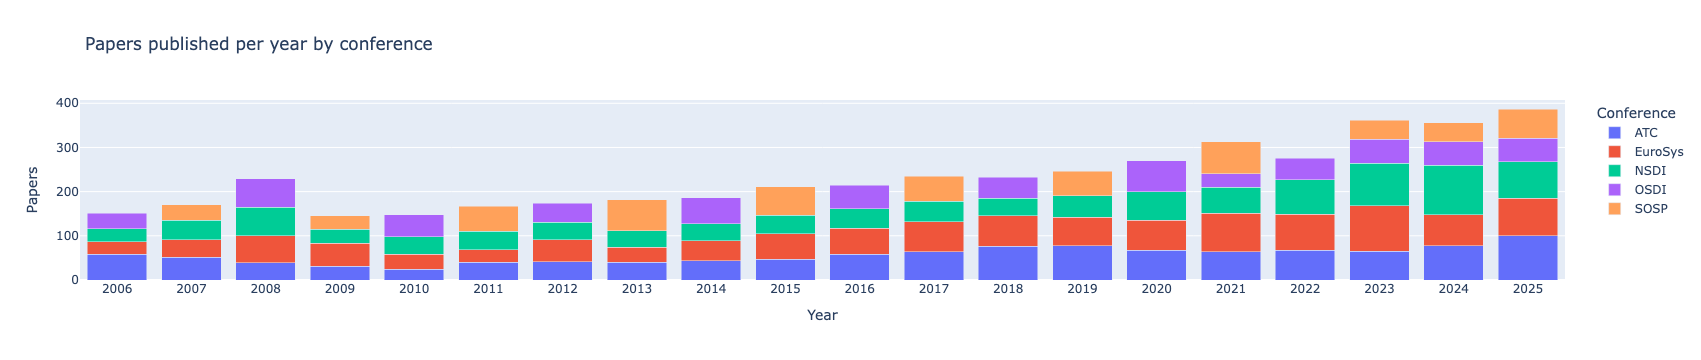

In [2]:
df = papers_over_time(editions)

fig = px.bar(
    df, x="year", y="paper_count", color="conference",
    barmode="stack",
    title="Papers published per year by conference",
    labels={"paper_count": "Papers", "year": "Year", "conference": "Conference"},
)
fig.update_layout(xaxis=dict(dtick=1), hovermode="x unified")
fig.show()

## 2 · Paper title keyword heatmap

A heatmap of how frequently individual keywords appear in paper titles, broken down
by year. Rows are the top-25 most frequent keywords (after removing a curated list of
generic words — see `heatmap_stopwords.txt`); columns are years.

**Aggregation:** for each year, all paper titles are tokenised into lowercase
alphabetic tokens of at least 3 characters. A term–year count matrix is built from
these tokens. The top-25 terms by total count across all years are selected as rows.
Cell colour encodes raw occurrence count (not normalised).

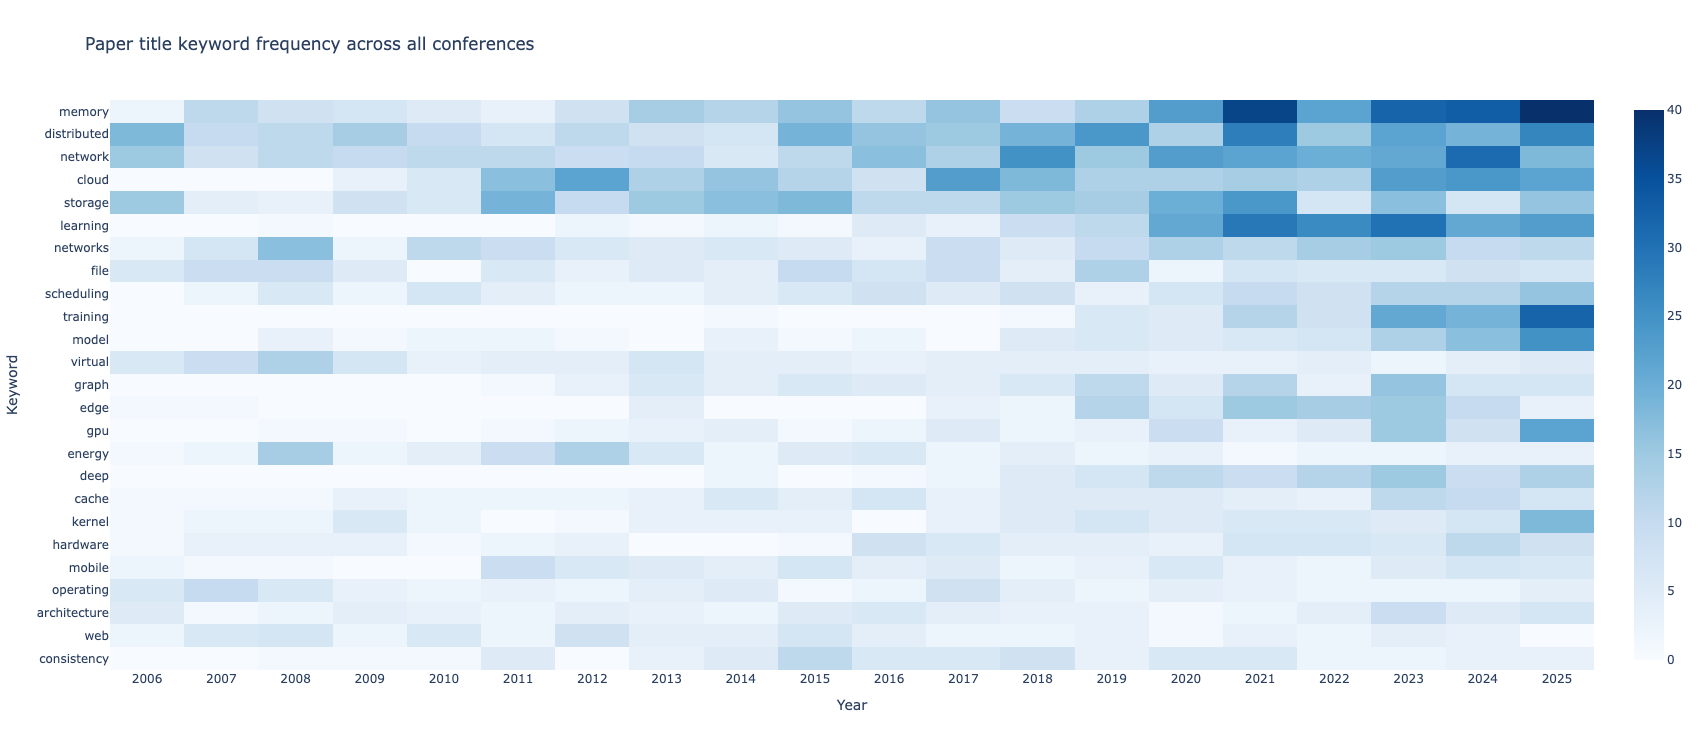

In [3]:
matrix = keyword_heatmap_matrix(editions, top_n=25)

fig = go.Figure(go.Heatmap(
    z=matrix.values,
    x=[str(y) for y in matrix.columns],
    y=matrix.index.tolist(),
    colorscale="Blues",
    hovertemplate="Keyword: %{y}<br>Year: %{x}<br>Count: %{z}<extra></extra>",
))
fig.update_layout(
    title="Paper title keyword frequency across all conferences",
    xaxis_title="Year",
    yaxis_title="Keyword",
    height=750,
    yaxis=dict(autorange="reversed"),
)
fig.show()

## 3 · Topic trend lines

Each paper is assigned to one of the 16 research topics from the SOSP 2026 Call for
Papers (`sosp26_topics.txt`), and the fraction of papers assigned to each topic is
plotted per year.

**Methodology:**
1. **Embedding:** paper titles and topic names are encoded with
   [`google/embeddinggemma-300m`](https://huggingface.co/google/embeddinggemma-300m),
   a 300 M-parameter embedding model fine-tuned for asymmetric retrieval. Topic names
   are encoded as *queries* (`encode_query`) and paper titles as *documents*
   (`encode_document`). Embeddings are pre-computed once via `make embed` and cached
   in `data/embeddings.npz`.
2. **Assignment:** for each paper, cosine similarity is computed against all 16 topic
   vectors. The paper is assigned to the topic with the highest similarity score.
3. **Frequency:** for each (year, topic) pair, frequency = papers assigned to that
   topic / total papers that year.

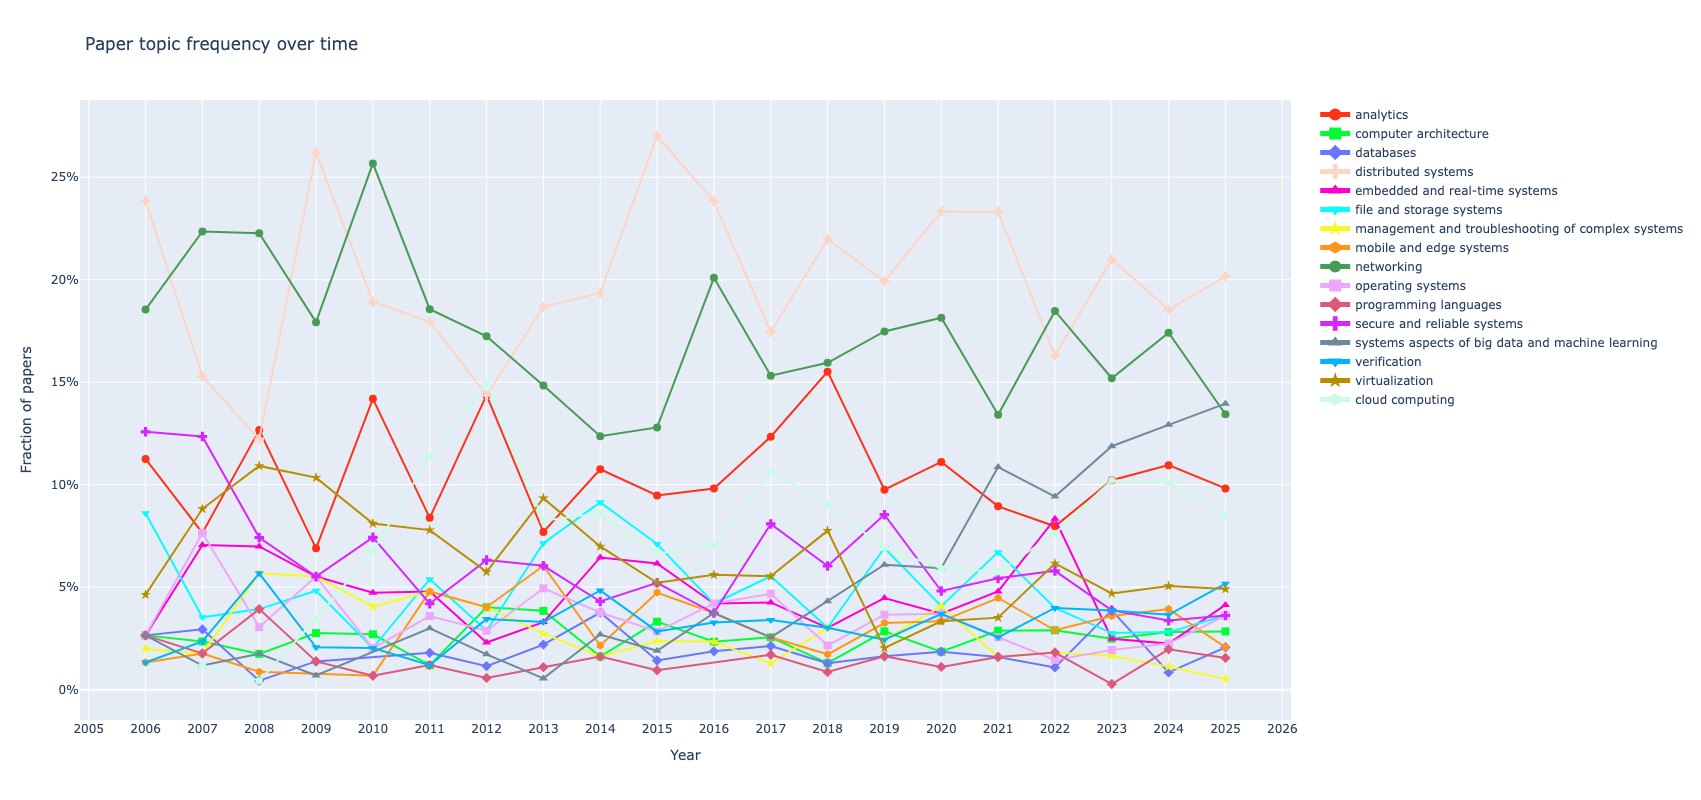

In [4]:
import plotly.graph_objects as go

trends = topic_trends_from_embeddings(DATA_DIR / "embeddings.npz")

topics_ordered = trends["topic"].unique().tolist()

# 16 visually distinct colours
colors = px.colors.qualitative.Light24[:len(topics_ordered)]

# 8 distinct marker symbols, cycled
symbols = [
    "circle", "square", "diamond", "cross",
    "triangle-up", "triangle-down", "star", "hexagon",
]

fig = go.Figure()
for i, topic in enumerate(topics_ordered):
    df_t = trends[trends["topic"] == topic]
    fig.add_scatter(
        x=df_t["year"], y=df_t["frequency"],
        mode="lines+markers",
        name=topic,
        line=dict(color=colors[i]),
        marker=dict(symbol=symbols[i % len(symbols)], size=8, color=colors[i]),
    )

fig.update_layout(
    title="Paper topic frequency over time",
    xaxis=dict(dtick=1, title="Year"),
    yaxis=dict(tickformat=".0%", title="Fraction of papers"),
    hovermode="x unified",
    height=800,
    legend=dict(itemsizing="constant"),
)
fig.show()

## 4 · Determinism or deterministic in paper titles

A bar chart counting how many paper titles contain the substring `determinis`
(matching *determinism*, *deterministic*, *deterministically*) in each year.

**Aggregation:** case-insensitive substring search over all paper titles. Raw count
per year — not normalised by total papers.

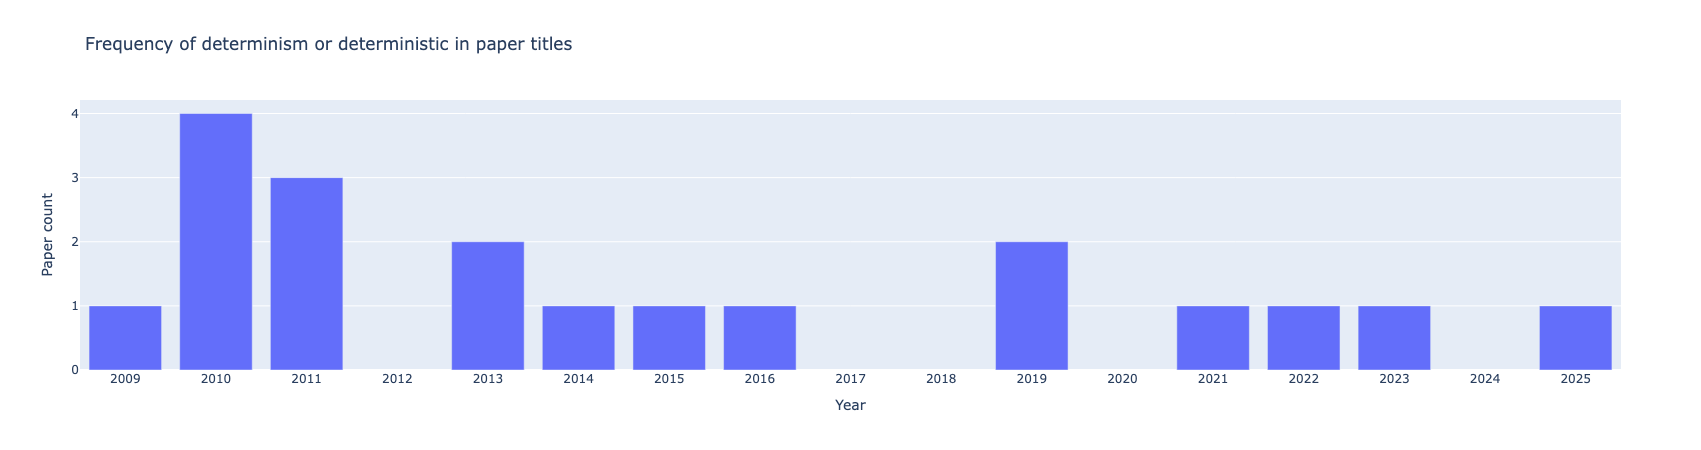

In [5]:
from collections import defaultdict

counts_by_year: dict[int, int] = defaultdict(int)

for e in editions:
    for p in e["papers"]:
        if "determinis" in p["title"].lower():
            counts_by_year[e["year"]] += 1

years = sorted(counts_by_year)
abs_counts = [counts_by_year[y] for y in years]

import plotly.graph_objects as go
fig = go.Figure()
fig.add_bar(x=years, y=abs_counts, name="Paper count")
fig.update_layout(
    title="Frequency of determinism or deterministic in paper titles",
    xaxis=dict(dtick=1, title="Year"),
    yaxis=dict(title="Paper count"),
    hovermode="x unified",
    height=450,
)
fig.show()

## 5 · Conference topic-overlap

A symmetric heatmap showing how similar each pair of conferences is in terms of the
vocabulary used in their paper titles.

**Methodology (Jaccard similarity):** for each conference, the top-200 most frequent
words across all its paper titles (after generic-word filtering) form a word set.
Pairwise Jaccard similarity is computed as:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A value of 1.0 means the two conferences use identical top-200 words; 0.0 means no
overlap. The diagonal is always 1.0 (a conference compared with itself).

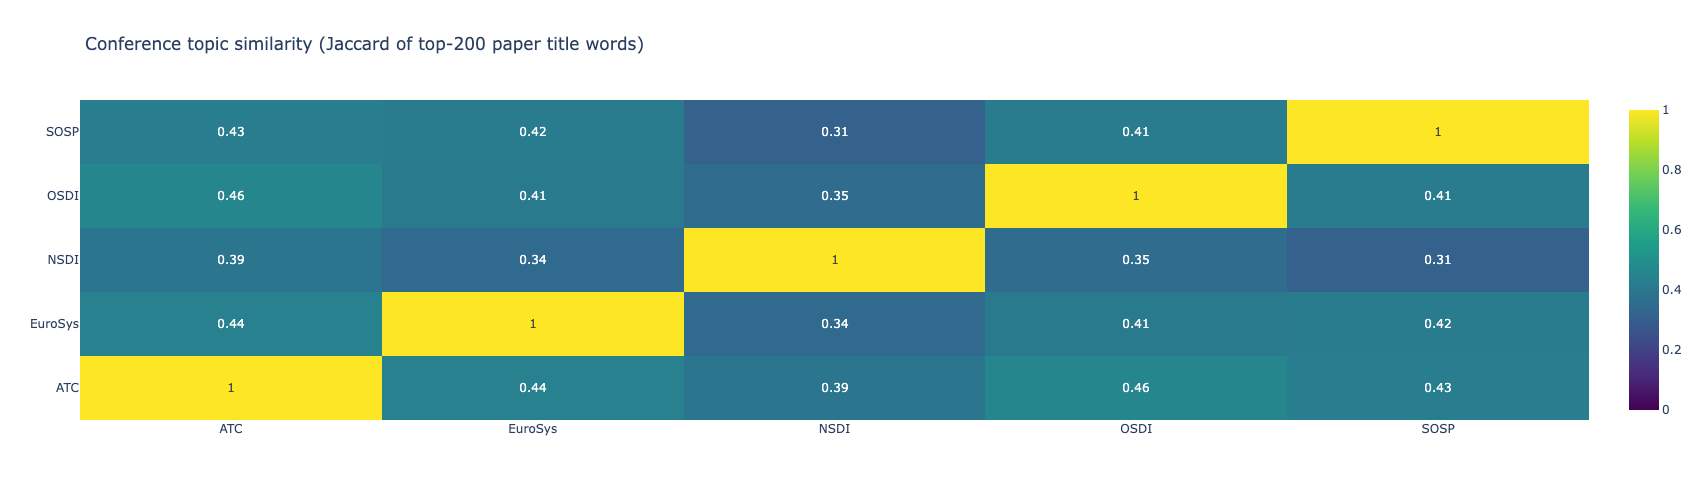

In [6]:
sim = conference_similarity(editions)
confs = sim.index.tolist()

fig = go.Figure(go.Heatmap(
    z=sim.values,
    x=confs,
    y=confs,
    colorscale="Viridis",
    zmin=0, zmax=1,
    text=np.round(sim.values, 2),
    texttemplate="%{text}",
    hovertemplate="%{y} vs %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title="Conference topic similarity (Jaccard of top-200 paper title words)",
    height=500,
)
fig.show()